## BIL462 Project Source Codes | 2024-2025 Fall | Context: Iris Recognition on UBIRIS.v2 Dataset

#### Step1: Sentetic Noise Addition (Image Processing)

In [14]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install tqdm

import os
import cv2
import numpy as np
from tqdm import tqdm

Note: you may need to restart the kernel to use updated packages.


In [16]:
# Function to add motion blur to an image
def add_motion_blur(image, kernel_size=15):
    """
    Apply motion blur to the image using a linear kernel.
    """
    # Create a kernel filled with zeros of shape (kernel_size x kernel_size)
    kernel = np.zeros((kernel_size, kernel_size))
    
    # Set the middle row to ones to simulate horizontal motion blur
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
    
    # Normalize the kernel by dividing by the kernel size
    kernel = kernel / kernel_size
    
    # Apply the kernel to the image using convolution (2D filter)
    blurred = cv2.filter2D(image, -1, kernel)
    
    # Return the blurred image
    return blurred

# Function to simulate low-light conditions using gamma correction
def apply_low_light(image, gamma=0.3):
    """
    Apply gamma correction to simulate low-light conditions.
    """
    # Calculate inverse gamma value
    inv_gamma = 1.0 / gamma
    
    # Build a lookup table for all pixel values [0, 255] after gamma correction
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    
    # Apply the gamma correction using the lookup table
    low_light_image = cv2.LUT(image, table)
    
    # Return the gamma-corrected (darker) image
    return low_light_image

# Define the path to the input dataset folder (original images)
input_folder = "001"

# Define the path to the output folder where modified images will be saved
output_folder = "CLASSES_400_300_noised"

# Create the output folder if it doesn't already exist
os.makedirs(output_folder, exist_ok=True)


In [17]:
# Counters for tracking how many images receive each type of noise
motion_blur_count = 0
low_light_count = 0
both_count = 0

# Loop through all image files in the input folder
for image_name in tqdm(os.listdir(input_folder)):

    # Get full path to the image file
    image_path = os.path.join(input_folder, image_name)

    # Read the image in color mode
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # If the image could not be read, print an error and skip
    if image is None:
        print(f"Error reading image {image_path}")
        continue

    # Create a copy of the image to apply noise filters
    noisy_image = image.copy()

    # Randomly select one of the filters to apply with given probabilities
    filters = np.random.choice(["motion_blur", "low_light", "both"], p=[0.4, 0.4, 0.2])

    # Apply motion blur only
    if filters == "motion_blur":
        noisy_image = add_motion_blur(noisy_image, kernel_size=15)
        motion_blur_count += 1

    # Apply low-light effect only
    elif filters == "low_light":
        noisy_image = apply_low_light(noisy_image, gamma=0.4)
        low_light_count += 1

    # Apply both motion blur and low-light
    else:  # both
        noisy_image = add_motion_blur(noisy_image, kernel_size=15)
        noisy_image = apply_low_light(noisy_image, gamma=0.4)
        both_count += 1

    # Save the filtered image to the output folder
    output_path = os.path.join(output_folder, image_name)
    cv2.imwrite(output_path, noisy_image)

# After processing all images, calculate and print statistics
total_images = len(os.listdir(input_folder))
print("Noisy images were successfully created.")
print("Total number of images:", total_images)
print("Output folder:", output_folder)
print("Filter Application Rate (motion_blur):", motion_blur_count / total_images)
print("Filter Application Rate (low_light):", low_light_count / total_images)
print("Filter Application Rate (both):", both_count / total_images)


100%|██████████| 30/30 [00:00<00:00, 200.63it/s]

Noisy images were successfully created.
Total number of images: 30
Output folder: CLASSES_400_300_noised
Filter Application Rate (motion_blur): 0.5
Filter Application Rate (low_light): 0.26666666666666666
Filter Application Rate (both): 0.23333333333333334


#### Step2: Data Augmentation

In [18]:
import numpy as np
import glob
import cv2
import os

# Paths for input and output folders
input_folder = r"CLASSES_400_300"
output_folder = r"CLASSES_400_300_augmented"
os.makedirs(output_folder, exist_ok=True)  # Create output folder if it doesn't exist

# Function to rotate an image 90 degrees clockwise
def rotate_image(image, label, number):
    rotated_image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    output_path = os.path.join(output_folder, f"{label}_rotate_{number}.jpg")
    cv2.imwrite(output_path, rotated_image)

# Function to flip the image
# direction = 0 (vertical), 1 (horizontal), -1 (both)
def flip_image(image, direction, label, number):
    flipped_image = cv2.flip(image, direction)
    output_path = os.path.join(output_folder, f"{label}_flip_{direction}_{number}.jpg")
    cv2.imwrite(output_path, flipped_image)

# Function to change image brightness using gamma correction
def add_light(image, gamma, label, number):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    brightened_image = cv2.LUT(image, table)
    output_path = os.path.join(output_folder, f"{label}_light_{gamma}_{number}.jpg")
    cv2.imwrite(output_path, brightened_image)

# Main augmentation function
def augment_images(input_folder, percentage):
    """
    Augments images in the specified folder and generates new images
    based on the given percentage.

    Args:
        input_folder (str): Path to the input images folder.
        percentage (float): Target percentage of new images to generate.
    
    Operation:
        - Collects all .tiff files in the folder.
        - Calculates how many new images to create based on the total number.
        - For each image, applies augmentation:
            - Rotation
            - Flipping
            - Brightness increase
            - Brightness decrease
        - Stops when the target number of new images is reached.
        - Prints the number of new images created.
    """
    images = glob.glob(os.path.join(input_folder, "*.tiff"))  # Get all .tiff files
    total_images = len(images)
    target_count = int(total_images * (percentage / 100))  # Calculate target image count
    count = 0  # Counter for how many new images created
    
    for filepath in images:
        if count >= target_count:
            break  # Stop if target reached

        filename = os.path.basename(filepath)
        image = cv2.imread(filepath)
        label = os.path.splitext(filename)[0]  # Use filename (without extension) as label

        # Apply augmentations one by one
        rotate_image(image, label, count)
        count += 1
        if count >= target_count: break

        flip_image(image, 0, label, count)  # Vertical flip
        count += 1
        if count >= target_count: break

        add_light(image, 1.5, label, count)  # Brighten
        count += 1
        if count >= target_count: break

        add_light(image, 0.7, label, count)  # Darken
        count += 1
        if count >= target_count: break

    print(f"{count} images (%{percentage}) were successfully generated and saved.")

# Define percentage N (e.g., 20% of total images)
N = 20
augment_images(input_folder, N)


0 images (%20) were successfully generated and saved.


#### Step3: Image Enhancement (DeepLearning)

In [19]:
!pip install matplotlib

In [20]:
%pip install torch torchvision scikit-image

import os
import cv2
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

Note: you may need to restart the kernel to use updated packages.


In [22]:
# Define a custom dataset class for noise reduction tasks
class NoiseReductionDataset(Dataset):
    def __init__(self, noisy_folder, original_folder, transform=None):
        # Get sorted lists of filenames from both noisy and original image folders
        self.noisy_images = sorted(os.listdir(noisy_folder))
        self.original_images = sorted(os.listdir(original_folder))
        self.noisy_folder = noisy_folder
        self.original_folder = original_folder
        self.transform = transform  # Any transformations (e.g., ToTensor)

    def __len__(self):
        # Return the total number of image pairs
        return len(self.noisy_images)

    def __getitem__(self, idx):
        # Build the full paths to the noisy and original image files
        noisy_path = os.path.join(self.noisy_folder, self.noisy_images[idx])
        original_path = os.path.join(self.original_folder, self.original_images[idx])

        # Read the images using OpenCV in color mode (BGR)
        noisy_image = cv2.imread(noisy_path, cv2.IMREAD_COLOR)
        original_image = cv2.imread(original_path, cv2.IMREAD_COLOR)

        # Apply the transformations (e.g., convert to PIL and then to tensor)
        if self.transform:
            noisy_image = self.transform(noisy_image)
            original_image = self.transform(original_image)

        # Return the transformed noisy image, original image, and filename
        return noisy_image, original_image, os.path.basename(noisy_path)


# Define the transformations to be applied to images
transform = transforms.Compose([
    transforms.ToPILImage(),   # Convert from NumPy array (OpenCV) to PIL image
    transforms.ToTensor(),     # Convert from PIL image to Torch tensor (normalized [0, 1])
])

# Define dataset and data loader paths
noisy_folder = "CLASSES_400_300_noised"             # Folder containing noisy images
original_folder = "001"   # Folder containing original (clean) images

# Create dataset instance with transformations applied
dataset = NoiseReductionDataset(noisy_folder, original_folder, transform=transform)


In [23]:
# Calculate dataset sizes for training, validation, and testing
train_size = int(0.7 * len(dataset))       # 70% of the dataset for training
val_size = int(0.15 * len(dataset))        # 15% of the dataset for validation
test_size = len(dataset) - train_size - val_size  # Remaining 15% for testing

# Randomly split the dataset into training, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)   # Shuffle training data for better generalization
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)      # No shuffle for validation
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)    # No shuffle for testing


In [24]:
# DenseNet Encoder and Complex Decoder Model
class DenseNetModel(nn.Module):
    def __init__(self):
        super(DenseNetModel, self).__init__()

        # Use DenseNet121 pre-trained on ImageNet as encoder, only use its feature extractor
        self.encoder = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).features

        # Custom decoder to reconstruct image from DenseNet features
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1024, 512, kernel_size=3, stride=2, padding=1, output_padding=1),  # Upsample 1024 → 512
            nn.ReLU(),

            nn.Conv2d(512, 256, kernel_size=3, padding=1),  # Convolution for refinement
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # Upsample 256 → 128
            nn.ReLU(),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),  # Further refinement
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # Final upsample to 3 channels
            nn.Tanh()  # Output scaled between [-1, 1] to reduce color artifacts
        )

    def forward(self, x,return_feature=False):
        original_size = x.size()[2:]  # Save original input image size (height, width)
        x = self.encoder(x)  # Pass through encoder
        if(return_feature):
            return x;
        x = self.decoder(x)  # Pass through decoder
        x = F.interpolate(x, size=original_size, mode="bilinear", align_corners=False)  # Resize back to original size
        return x

# Loss Function (MSE + SSIM)
class CombinedLoss(nn.Module):
    def __init__(self, data_range=1.0):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()  # Mean Squared Error Loss
        self.data_range = data_range  # Range of input image values (e.g., 1.0 if normalized)

    def forward(self, outputs, targets):
        mse_loss = self.mse(outputs, targets)  # Compute MSE loss

        # Convert tensors to NumPy arrays for SSIM calculation
        outputs_np = outputs.detach().cpu().numpy()
        targets_np = targets.cpu().numpy()

        # Compute SSIM loss for each image in batch and average
        ssim_loss = np.mean([
            1 - ssim(
                targets_np[i].transpose(1, 2, 0),  # Convert from CHW to HWC format
                outputs_np[i].transpose(1, 2, 0),
                channel_axis=-1,
                data_range=self.data_range
            )
            for i in range(len(outputs_np))
        ])

        return mse_loss + 0.5 * ssim_loss  # Combine MSE and SSIM losses (weighted)

# PSNR (Peak Signal-to-Noise Ratio) Calculation Function
def calculate_psnr(mse):
    return 20 * np.log10(1.0 / np.sqrt(mse))  # PSNR formula assuming max pixel value = 1.0






    # def forward(self, x, return_feature=False):
    #     original_size = x.size()[2:]
    #     feat = self.encoder(x)  # (B, 1024, 7, 7) for 224×224 input

    #     if return_feature:
    #         return feat  # Return encoder feature directly

    #     x = self.decoder(feat)
    #     x = F.interpolate(x, size=original_size, mode="bilinear", align_corners=False)
    #     return x

In [25]:
# Install PyTorch with CUDA support (only run this in Jupyter Notebook if needed)
# %pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

# Set the device to GPU (CUDA) if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the selected device
model = DenseNetModel().to(device)

# Define the loss function (combination of MSE and SSIM for image quality)
criterion = CombinedLoss()

# Use Adam optimizer for training with a small learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Set up a learning rate scheduler to reduce LR when validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Print PyTorch version and check if CUDA (GPU) is available
print("Torch Version:", torch.__version__, ", CUDA Available:", torch.cuda.is_available())

# Lists to store training and validation metrics over epochs
train_mse, val_mse = [], []       # Mean Squared Error
train_ssim, val_ssim = [], []     # Structural Similarity Index
train_psnr, val_psnr = [], []     # Peak Signal-to-Noise Ratio


Torch Version: 2.7.1+cu126 , CUDA Available: True


In [26]:
# Training Loop
num_epochs = 20  # Number of training epochs
best_val_loss = float("inf")  # Initialize best validation loss to a very high value

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_train_mse, epoch_train_ssim, epoch_train_psnr = 0, 0, 0  # Initialize training metrics for this epoch

    # Loop over training data
    for noisy_images, original_images, _ in tqdm(train_loader):
        noisy_images = noisy_images.to(device)        # Move noisy images to GPU (if available)
        original_images = original_images.to(device)  # Move original images to GPU (if available)

        # Forward pass: generate predictions
        outputs = model(noisy_images)

        # Compute loss between predicted and original images
        loss = criterion(outputs, original_images)

        # Backward pass and optimization
        optimizer.zero_grad()  # Clear existing gradients
        loss.backward()        # Backpropagate the loss
        optimizer.step()       # Update model weights

        # Accumulate training loss
        epoch_train_mse += loss.item()

        # Convert predictions and targets to NumPy arrays for SSIM calculation
        outputs_np = outputs.detach().cpu().numpy()
        original_np = original_images.cpu().numpy()

        # Compute SSIM for each image in the batch
        batch_ssim = np.mean([
            ssim(
                original_np[i].transpose(1, 2, 0),  # Convert from [C, H, W] to [H, W, C]
                outputs_np[i].transpose(1, 2, 0),
                channel_axis=-1,
                data_range=1.0
            )
            for i in range(len(outputs_np))
        ])
        epoch_train_ssim += batch_ssim  # Accumulate SSIM

        # Compute PSNR for the batch and accumulate
        batch_psnr = calculate_psnr(loss.item())
        epoch_train_psnr += batch_psnr

    # Compute average training metrics for the epoch
    train_mse.append(epoch_train_mse / len(train_loader))
    train_ssim.append(epoch_train_ssim / len(train_loader))
    train_psnr.append(epoch_train_psnr / len(train_loader))

    # === Validation Phase ===
    model.eval()  # Set model to evaluation mode
    epoch_val_mse, epoch_val_ssim, epoch_val_psnr = 0, 0, 0

    with torch.no_grad():  # Disable gradient computation for validation
        for noisy_images, original_images, _ in val_loader:
            noisy_images = noisy_images.to(device)
            original_images = original_images.to(device)

            outputs = model(noisy_images)
            loss = criterion(outputs, original_images)
            epoch_val_mse += loss.item()

            outputs_np = outputs.cpu().numpy()
            original_np = original_images.cpu().numpy()

            # Compute SSIM for validation batch
            batch_ssim = np.mean([
                ssim(
                    original_np[i].transpose(1, 2, 0),
                    outputs_np[i].transpose(1, 2, 0),
                    channel_axis=-1,
                    data_range=1.0  # Assumes image values are scaled between [0, 1]
                )
                for i in range(len(outputs_np))
            ])
            epoch_val_ssim += batch_ssim

            # Compute PSNR for validation batch
            batch_psnr = calculate_psnr(loss.item())
            epoch_val_psnr += batch_psnr

    # Compute average validation metrics
    val_mse.append(epoch_val_mse / len(val_loader))
    val_ssim.append(epoch_val_ssim / len(val_loader))
    val_psnr.append(epoch_val_psnr / len(val_loader))

    # Adjust learning rate if validation loss plateaus
    scheduler.step(val_mse[-1])

    # Print training and validation metrics for this epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}] - Train MSE: {train_mse[-1]:.4f}, Val MSE: {val_mse[-1]:.4f}, "
          f"Train SSIM: {train_ssim[-1]:.4f}, Val SSIM: {val_ssim[-1]:.4f}, "
          f"Train PSNR: {train_psnr[-1]:.2f}, Val PSNR: {val_psnr[-1]:.2f}")

    # Save the model if validation loss improves
    if val_mse[-1] < best_val_loss:
        best_val_loss = val_mse[-1]
        torch.save(model.state_dict(), "best_densenet_model.pth")


100%|██████████| 3/3 [00:00<00:00,  4.15it/s]


Epoch [1/20] - Train MSE: 0.5857, Val MSE: 0.5299, Train SSIM: 0.0895, Val SSIM: 0.1496, Train PSNR: 2.33, Val PSNR: 2.76


100%|██████████| 3/3 [00:00<00:00,  7.77it/s]


Epoch [2/20] - Train MSE: 0.5041, Val MSE: 0.5028, Train SSIM: 0.1381, Val SSIM: 0.1348, Train PSNR: 2.98, Val PSNR: 2.99


100%|██████████| 3/3 [00:00<00:00,  7.36it/s]


...

Epoch [18/20] - Train MSE: 0.3014, Val MSE: 0.2911, Train SSIM: 0.4154, Val SSIM: 0.4395, Train PSNR: 5.21, Val PSNR: 5.36


100%|██████████| 3/3 [00:00<00:00,  8.00it/s]


Epoch [19/20] - Train MSE: 0.2868, Val MSE: 0.2798, Train SSIM: 0.4425, Val SSIM: 0.4654, Train PSNR: 5.43, Val PSNR: 5.53


100%|██████████| 3/3 [00:00<00:00,  7.93it/s]


Epoch [20/20] - Train MSE: 0.2746, Val MSE: 0.2707, Train SSIM: 0.4654, Val SSIM: 0.4807, Train PSNR: 5.62, Val PSNR: 5.68


In [27]:
# Test Performansı
model.load_state_dict(torch.load("best_densenet_model.pth", weights_only=True))
model.eval()
test_mse, test_ssim, test_psnr = 0, 0, 0

denoised_folder = "CLASSES_400_300_denoised"
os.makedirs(denoised_folder, exist_ok=True)

with torch.no_grad():
    for noisy_images, original_images, file_names in tqdm(test_loader):
        noisy_images = noisy_images.to(device)
        original_images = original_images.to(device)

        outputs = model(noisy_images)
        loss = criterion(outputs, original_images)

        test_mse += loss.item()
        outputs_np = outputs.cpu().numpy()
        original_np = original_images.cpu().numpy()

        batch_ssim = np.mean([
            ssim(original_np[i].transpose(1, 2, 0),
                outputs_np[i].transpose(1, 2, 0),
                channel_axis=-1,
                data_range=1.0)
            for i in range(len(outputs_np))
        ])
        test_ssim += batch_ssim

        batch_psnr = calculate_psnr(loss.item())
        test_psnr += batch_psnr

        for i in range(outputs_np.shape[0]):
            restored = np.clip((outputs_np[i].transpose(1, 2, 0) * 255), 0, 255).astype(np.uint8)
            file_name = file_names[i]
            output_path = os.path.join(denoised_folder, file_name)
            cv2.imwrite(output_path, restored)

test_mse /= len(test_loader)
test_ssim /= len(test_loader)
test_psnr /= len(test_loader)

print(f"Test MSE: {test_mse:.4f}, Test SSIM: {test_ssim:.4f}, Test PSNR: {test_psnr:.2f}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 10.63it/s]

Test MSE: 0.2741, Test SSIM: 0.4748, Test PSNR: 5.62


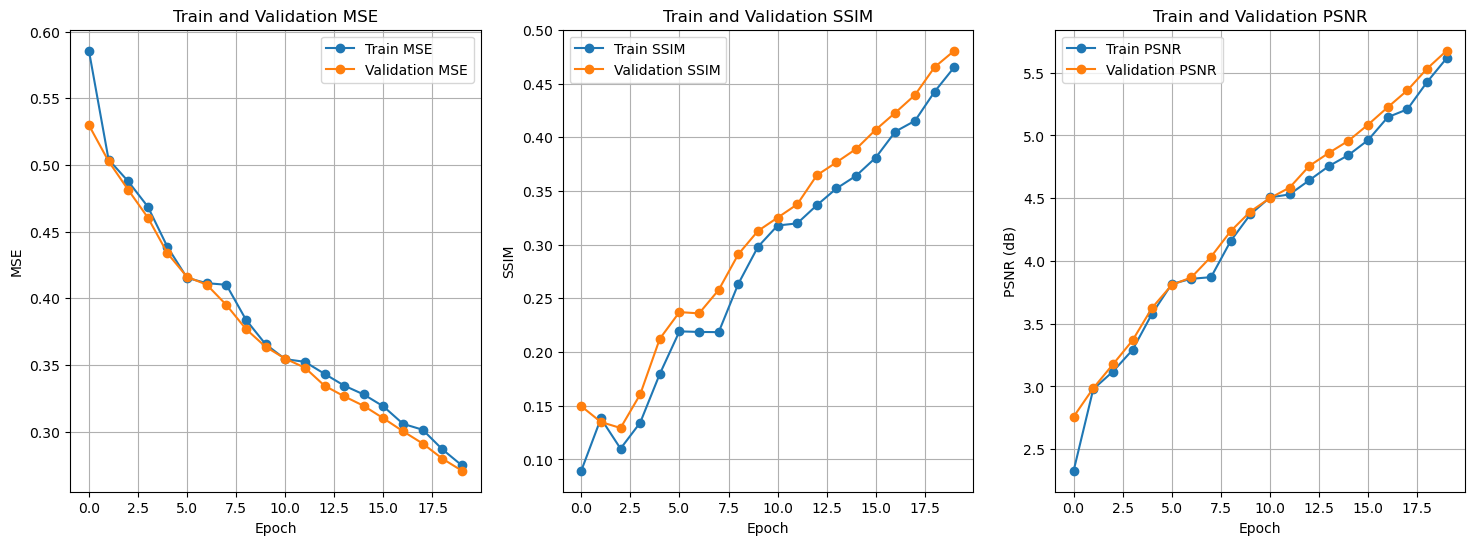

In [28]:
# Kayıp ve Metrik Grafiklerini Çiz
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(train_mse, label="Train MSE", marker="o")
plt.plot(val_mse, label="Validation MSE", marker="o")
plt.title("Train and Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(train_ssim, label="Train SSIM", marker="o")
plt.plot(val_ssim, label="Validation SSIM", marker="o")
plt.title("Train and Validation SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(train_psnr, label="Train PSNR", marker="o")
plt.plot(val_psnr, label="Validation PSNR", marker="o")
plt.title("Train and Validation PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid()

plt.savefig("metrics_densenet.png")
plt.show()